# EEG Button Press Prediction — Simple BCI Pipeline

**Based on:** *I Built a Brain-Computer Interface to Play Space Invaders Using Thoughts*  
**Adapted for:** MRCP (Movement-Related Cortical Potential) detection, Go/No-Go task.

The Space Invaders BCI used:
1. Bandpass filter → Common Average Reference (CAR)
2. Common Spatial Patterns (CSP) for spatial filtering
3. LDA / SVM / Random Forest classifier

Here we replace CSP with per-channel temporal + frequency features and use LightGBM.

| Step | Detail |
|------|--------|
| Bandpass | 0.5–8 Hz (MRCP delta/theta band) |
| T | 1000 ms window |
| Horizon | 500 ms look-ahead |
| Features | mean, std, slope, RMS, delta power, theta power × 6 channels = 36 total |
| CV | Leave-One-Trial-Out per subject |

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import butter, sosfiltfilt
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

FS        = 250                                              # sampling rate (Hz)
T         = 250                                              # window = 1000 ms
HORIZON   = 125                                              # predict press within 500 ms
LP, HP    = 0.5, 8.0                                         # bandpass cut-offs (Hz)
CHANNELS  = [f"ch{i}" for i in range(1, 17)]#['ch2', 'ch3', 'ch4', 'ch10', 'ch11', 'ch12']    # over motor cortex
DATA_ROOT = Path('../data')
TACHE     = 'gng'
SUBJECTS  = [0]

print(f'Window: {T/FS*1000:.0f} ms  Horizon: {HORIZON/FS*1000:.0f} ms  '
      f'Channels: {len(CHANNELS)}  Features: {6 * len(CHANNELS)}')

Window: 1000 ms  Horizon: 500 ms  Channels: 16  Features: 96


## 1. Load and Preprocess

Three steps, same as the Space Invaders pipeline:
1. **Bandpass 0.5–8 Hz** — keeps the MRCP slow negative ramp, rejects DC drift and high-freq noise
2. **Common Average Reference (CAR)** — subtract mean across channels at each time step to reduce global noise
3. **Trial z-score** — normalise amplitude per channel; removes session-level amplitude drift

In [11]:
sos = butter(4, [LP, HP], btype='bandpass', fs=FS, output='sos')

raw_trials = {}   # subj -> [(X, y), ...]

for subj in SUBJECTS:
    subj_path = DATA_ROOT / f'subject{subj}'
    files     = sorted(subj_path.glob(f'subject_{subj}_tache_{TACHE}_trial_*.csv'))
    raw_trials[subj] = []

    for fpath in files:
        df = pd.read_csv(fpath, sep=';')
        X  = df[CHANNELS].values.astype(np.float64)           # (N, C)
        y  = df['button'].values.astype(np.int8)              # (N,)

        X = sosfiltfilt(sos, X, axis=0)                       # 1. Bandpass
        X -= X.mean(axis=1, keepdims=True)                    # 2. CAR
        X = (X - X.mean(0)) / (X.std(0) + 1e-8)               # 3. Z-score
        y = np.diff(y, prepend=0).clip(0).astype(np.int8)     # rising edge only

        raw_trials[subj].append((X.astype(np.float32), y))

    n_presses = int(sum(t[1].sum() for t in raw_trials[subj]))
    print(f'Subject {subj}: {len(raw_trials[subj])} trials, {n_presses} presses')

Subject 0: 12 trials, 357 presses


## 2. Windowing, Horizon Labels and Feature Extraction

For each sample position `i` in `[T, N)`:
- **Window**: `X[i-T : i]` — the 1000 ms of EEG ending at position i
- **Label**: 1 if a press occurs in `y[i : i+HORIZON]`, else 0

This is the causal MRCP setup: the window captures the 1 s negative ramp that precedes a voluntary movement, and the label checks whether a press follows within 500 ms.

Features per window (6 channels × 6 stats = 36 features total):
- **Temporal**: mean, std, slope, RMS
- **Frequency**: delta (0.5–4 Hz) and theta (4–8 Hz) band power via FFT

In [12]:
def make_features_and_labels(X, y_mom, T, horizon, fs):
    """
    X      : (N, C) float32  preprocessed EEG
    y_mom  : (N,)   int8     rising-edge button labels
    Returns: feats (M, 6C) float32, labels (M,) int8   where M = N - T
    """
    N, C = X.shape
    M    = N - T

    # Horizon labels: y_h[i] = 1 if a press occurs in y_mom[i : i+horizon]
    cs    = np.concatenate([[0], np.cumsum(y_mom.astype(np.int64))])
    y_h   = np.zeros(N, dtype=np.int8)
    end   = N - horizon + 1
    if end > 0:
        y_h[:end] = (cs[horizon : horizon + end] - cs[:end] > 0)
    labels = y_h[T:]   # label for window ending at each sample i: y_h[i], i in [T, N)

    # Precompute FFT/slope constants
    t_c    = np.arange(T, dtype=np.float64) - (T - 1) / 2.0
    t_var  = (t_c ** 2).sum() + 1e-12
    freqs  = np.fft.rfftfreq(T, d=1.0 / fs)
    d_mask = (freqs >= 0.5) & (freqs < 4.0)   # delta band
    t_mask = (freqs >= 4.0) & (freqs < 8.0)   # theta band

    # Process in batches to keep memory manageable
    BATCH  = 5_000
    chunks = []

    for b0 in range(0, M, BATCH):
        b1 = min(b0 + BATCH, M)
        # w[k] = X[b0+k : b0+k+T], shape (B, T, C)
        w  = np.stack([X[i : i + T] for i in range(b0, b1)]).astype(np.float64)

        # Temporal features
        mean  = w.mean(1)                                     # (B, C)
        std   = w.std(1)
        slope = (w * t_c[None, :, None]).sum(1) / t_var
        rms   = np.sqrt((w ** 2).mean(1))

        # Frequency features (FFT magnitude squared)
        fft2  = np.abs(np.fft.rfft(w, axis=1)) ** 2          # (B, T//2+1, C)
        delta = fft2[:, d_mask, :].mean(1)                   # (B, C)
        theta = fft2[:, t_mask, :].mean(1)

        chunks.append(
            np.concatenate([mean, std, slope, rms, delta, theta], axis=1).astype(np.float32)
        )

    return np.concatenate(chunks), labels

## 3. Build Dataset

In [13]:
processed = {}   # subj -> [(feats, labels), ...]

for subj, trials in raw_trials.items():
    processed[subj] = []
    for X, y in trials:
        feats, labels = make_features_and_labels(X, y, T, HORIZON, FS)
        processed[subj].append((feats, labels))

    total_w = sum(len(l) for _, l in processed[subj])
    total_p = int(sum(l.sum() for _, l in processed[subj]))
    print(f'Subject {subj}: {total_w:,} windows | '
          f'{total_p:,} positive ({total_p / total_w:.2%}) | '
          f'feat shape: {processed[subj][0][0].shape}')

Subject 0: 769,657 windows | 43,086 positive (5.60%) | feat shape: (37958, 96)


## 4. Leave-One-Trial-Out Cross-Validation

For each subject, one trial is held out as the test set while the remaining trials form the training set.  
This mirrors the online BCI scenario: the model never sees data from the test session.

In [14]:
results = {}   # subj -> [auc_fold0, auc_fold1, ...]

for subj, trial_data in processed.items():
    print(f'\nSubject {subj} — LOTO ({len(trial_data)} folds)')
    aucs = []

    for test_idx in range(len(trial_data)):
        F_test, y_test = trial_data[test_idx]

        if y_test.sum() == 0:
            print(f'  fold {test_idx}: skip (no presses in test trial)')
            continue

        train    = [trial_data[i] for i in range(len(trial_data)) if i != test_idx]
        F_train  = np.concatenate([f for f, _ in train])
        y_train  = np.concatenate([l for _, l in train])

        clf = lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            scale_pos_weight=50,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )
        clf.fit(F_train, y_train)

        proba = clf.predict_proba(F_test)[:, 1]
        auc   = roc_auc_score(y_test, proba)
        aucs.append(auc)
        print(f'  fold {test_idx}: AUC = {auc:.3f}  '
              f'({int(y_test.sum())} pos / {len(y_test):,} win)')

    results[subj] = aucs
    print(f'  -> mean AUC = {np.mean(aucs):.3f} +/- {np.std(aucs):.3f}')


Subject 0 — LOTO (12 folds)
  fold 0: AUC = 0.480  (1309 pos / 37,958 win)
  fold 1: AUC = 0.804  (3813 pos / 66,357 win)
  fold 2: AUC = 0.670  (3680 pos / 67,268 win)
  fold 3: AUC = 0.475  (3750 pos / 70,447 win)
  fold 4: AUC = 0.778  (3625 pos / 68,005 win)
  fold 5: AUC = 0.699  (3702 pos / 67,223 win)
  fold 6: AUC = 0.765  (3996 pos / 65,759 win)
  fold 7: AUC = 0.784  (3781 pos / 66,299 win)
  fold 8: AUC = 0.784  (3947 pos / 64,921 win)
  fold 9: AUC = 0.869  (3923 pos / 64,695 win)
  fold 10: AUC = 0.771  (3750 pos / 65,375 win)
  fold 11: AUC = 0.750  (3810 pos / 65,350 win)
  -> mean AUC = 0.719 +/- 0.118


## 5. Results

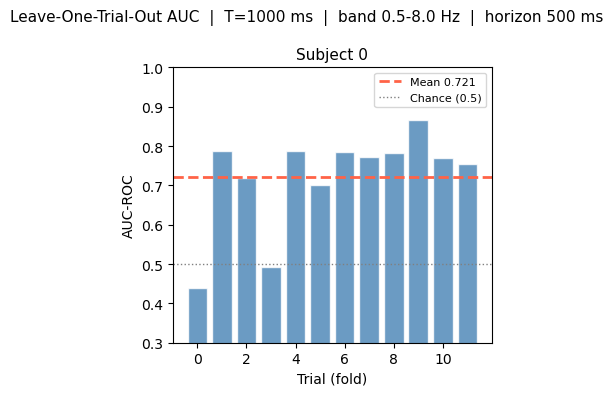


-- Summary --------------------------------------------------
  Subject  0:  0.721 +/- 0.121  (n=12)

  Overall:    0.721 +/- 0.121


In [8]:
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, (subj, aucs) in zip(axes, results.items()):
    ax.bar(range(len(aucs)), aucs, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axhline(np.mean(aucs), color='tomato', ls='--', lw=2,
               label=f'Mean {np.mean(aucs):.3f}')
    ax.axhline(0.5, color='gray', ls=':', lw=1, label='Chance (0.5)')
    ax.set_title(f'Subject {subj}', fontsize=11)
    ax.set_xlabel('Trial (fold)')
    ax.set_ylim(0.3, 1.0)
    if ax is axes[0]:
        ax.set_ylabel('AUC-ROC')
    ax.legend(fontsize=8)

plt.suptitle(
    f'Leave-One-Trial-Out AUC  |  T={T/FS*1000:.0f} ms  |  '
    f'band {LP}-{HP} Hz  |  horizon {HORIZON/FS*1000:.0f} ms',
    fontsize=11
)
plt.tight_layout()
plt.show()

all_aucs = [a for aucs in results.values() for a in aucs]
print('\n-- Summary --------------------------------------------------')
for subj, aucs in results.items():
    print(f'  Subject {subj:2d}:  {np.mean(aucs):.3f} +/- {np.std(aucs):.3f}  (n={len(aucs)})')
print(f'\n  Overall:    {np.mean(all_aucs):.3f} +/- {np.std(all_aucs):.3f}')